# 미션 소개
이번 미션은 기계 번역 실습으로, 한국어 문장을 영어로 번역하는 모델을 구축하는 프로젝트입니다. 총 3가지 모델(Seq2Seq 기본 모델, Attention 적용 모델)을 구현하고 학습시키며, 각 모델의 성능을 비교 분석해 보세요.

# 사용 데이터셋
- 데이터 형식
    - 미션에 사용되는 데이터셋은 JSON 파일 형식으로 제공되며, 각 항목은 한국어 문장("ko")과 영어 번역문("mt")으로 구성되어 있습니다.
- 파일 경로 예시
    - 훈련 데이터: `.../일상생활및구어체_한영_train_set.json`
    - 검증 데이터: `.../일상생활및구어체_한영_valid_set.json`

(파일 경로는 여러분의 환경에 맞게 수정해 주세요.)

# 가이드라인
- 데이터 전처리
  - 적절한 토크나이저를 선택하여 한국어, 영어 문장을 토큰화하세요.
  - 문장 길이를 분석하여, 전체 문장의 길이에 맞게 최대 길이(MAX_LENGTH)를 설정하고, 필요한 경우 SOS, EOS, PAD, UNK 등의 특수 토큰을 정의합니다.
- 어휘 사전 구축
  - 한국어와 영어 각각의 어휘 사전을 구성하세요.
  - 단어의 등장 빈도를 고려하여, 추후 임베딩이나 기타 모델 구성에 활용할 수 있습니다.
- 데이터셋 및 로더 구현
  - 각 문장을 토큰의 인덱스 시퀀스로 변환한 후, 고정 길이에 맞게 PAD 토큰으로 패딩합니다.
  - TensorDataset과 DataLoader를 활용하여 학습 데이터를 배치 단위로 효율적으로 처리할 수 있도록 구현하세요.
- 모델 구현 및 학습
  - Seq2Seq 모델
    - 기본 GRU 기반의 Encoder-Decoder 모델을 구현하고, Teacher Forcing 기법을 적용해 학습합니다.
  - Attention 모델
    - Bahdanau Attention(Bahdanau 혹은 Luong)을 적용한 디코더를 구현하여, 번역 성능을 높여 보세요.
- 모델 학습 및 평가
  - 각 모델별로 학습을 진행한 후, 평가 함수를 활용하여 번역 결과를 확인합니다.
  - 무작위 문장 쌍에 대해 모델의 번역 결과를 출력하고, 출력 문장을 정제(특수 토큰 제거 등)하여 성능을 분석해 보세요.
- 추가 실험 (선택)
  - 데이터 전처리 방법 개선(예: 불용어 제거, 정규화 등)
  - 모델 구조 변경(레이어 수, 은닉 상태 크기, Attention 기법 수정 등)
  - 하이퍼파라미터 튜닝(학습률, 배치 크기 등)
  - 다양한 평가 지표(예: BLEU 점수) 도입

## 제출 안내
다음 내용을 포함한 Colab Notebook 파일을 제출해 주세요.
파일 이름은 10_{팀명}_{성함}.ipynb 형태로 해 주세요.

1. 모델 구현 및 학습 결과
- 기계 번역 모델(Seq2Seq, Seq2Seq with Attention)을 구현하고, 데이터 로드 → 전처리 → 임베딩 적용 → 모델 구축 및 학습 → 예측 및 평가 과정을 순차적으로 진행하세요.
1. 마크다운을 활용한 설명
- 각 코드 셀이 수행하는 작업(의도, 알고리즘, 함수 설명 등)을 마크다운을 통해 자세히 기록해 주세요.
- 노트북 내에서 코드와 결과를 한눈에 이해할 수 있도록 정리해 주세요.
1. 모델 성능 평가 및 제출
- 생성된 텍스트의 품질을 정성적(번역 결과 확인) 및 정량적(BLUE 등, optional)으로 평가해 보세요.
테스트 데이터셋에 대한 번역 결과를 포함해 주세요.

## 참고 사항
- 미션을 시작할 때 도움이 필요하다면, Baseline 코드를 참고할 수 있습니다. 이 코드는 기본적인 코드로 제공되며, 여러분이 원하는 대로 자유롭게 변형할 수 있어요.
    - Baseline 코드 링크
    - 주의 사항: Baseline 코드는 여러분이 모델을 시작하는 데 도움을 주기 위한 참고 자료일 뿐이며, Baseline 코드를 그대로 사용하는 것보다는 이를 기반으로 자신의 아이디어를 추가하고 발전시키는 것이 중요합니다. 가능하면 스스로 모델을 구축해보고 다양한 방법을 시도하여 성능을 향상시켜 보세요.

## 1. 미션 범위와 목표

- 과제 목표: 한국어 문장을 영어 문장으로 번역하는 모델 구축
- 필수 모델: `Seq2Seq(GRU)`와 `Seq2Seq + Attention`
- 선택 모델: 시간 여유가 있을 때 `Transformer` 추가 실험
- 최종 목표: 정량/정성 평가를 통해 모델 성능을 비교하고 결론 도출


In [5]:
import random
import numpy as np
import torch
from pathlib import Path

# 1) 재현성 고정
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

# 2) 실행 장치 설정
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# 3) 미션 공통 설정(비교 실험 기준)
CFG = {
    "seed": SEED,
    "src_lang": "ko",
    "tgt_lang": "en",
    "required_models": ["seq2seq_gru", "seq2seq_attention"],
    "optional_models": ["transformer"],
    "max_length_policy": "p95_train_lengths",
    "batch_size": 64,
    "epochs": 10,
    "learning_rate": 1e-3,
    "teacher_forcing_ratio": 0.5,
    "metrics": ["train_loss", "valid_loss", "bleu_optional"]
}

# 4) 데이터 경로(현재 로컬 프로젝트 기준)
CONTENT_DIR = Path("./content/일상생활및구어체_한영")
DATA_PATHS = {
    "train_json": str(CONTENT_DIR / "일상생활및구어체_한영_train_set.json"),
    "valid_json": str(CONTENT_DIR / "일상생활및구어체_한영_valid_set.json"),
}

# 5) 진행 체크리스트
MISSION_CHECKLIST = [
    "JSON 데이터셋 로드(ko, mt)",
    "한/영 토큰화 및 전처리",
    "어휘 사전(vocab) 구축 및 인덱스 변환",
    "Seq2Seq / Attention 모델 학습",
    "정량/정성 평가 수행",
    "모델 비교 및 최종 결론 정리"
]

print("[1단계] 미션 기본 설정 완료")
print(f"- 실행 장치: {device}")
print(f"- 필수 모델: {CFG['required_models']}")
print(f"- 배치 크기 / 에폭: {CFG['batch_size']} / {CFG['epochs']}")
print(f"- Teacher Forcing 비율: {CFG['teacher_forcing_ratio']}")
print(f"- 훈련 데이터 경로: {DATA_PATHS['train_json']}")
print(f"- 검증 데이터 경로: {DATA_PATHS['valid_json']}")
print("\n[체크리스트]")
for i, item in enumerate(MISSION_CHECKLIST, start=1):
    print(f"{i}. [ ] {item}")


[1단계] 미션 기본 설정 완료
- 실행 장치: cuda
- 필수 모델: ['seq2seq_gru', 'seq2seq_attention']
- 배치 크기 / 에폭: 64 / 10
- Teacher Forcing 비율: 0.5
- 훈련 데이터 경로: content\일상생활및구어체_한영\일상생활및구어체_한영_train_set.json
- 검증 데이터 경로: content\일상생활및구어체_한영\일상생활및구어체_한영_valid_set.json

[체크리스트]
1. [ ] JSON 데이터셋 로드(ko, mt)
2. [ ] 한/영 토큰화 및 전처리
3. [ ] 어휘 사전(vocab) 구축 및 인덱스 변환
4. [ ] Seq2Seq / Attention 모델 학습
5. [ ] 정량/정성 평가 수행
6. [ ] 모델 비교 및 최종 결론 정리


## 2. 실험 설계 고정(공정 비교 기준)

모델 간 성능 비교의 공정성을 위해 다음 조건을 고정합니다.

- 동일한 토크나이저 및 전처리 규칙 사용
- 동일한 train/valid 분할 전략 사용
- 동일한 `MAX_LENGTH` 설정 기준 사용
- 동일한 학습 조건(optimizer, batch size, epoch 등) 유지
- 핵심 비교에서는 모델 구조(Attention 유무)만 변경


[폰트 설정] 사용 폰트: Malgun Gothic
[2단계] 데이터 로드 + EDA 완료
- 훈련 샘플 수 (원본 -> 정제): 1,200,000 -> 1,200,000
- 검증 샘플 수 (원본 -> 정제): 150,000 -> 150,000
- 제안 MAX_LENGTH (p95 기반): 22

[훈련 데이터 길이 통계 | 한국어]
  mean: 6.55
  median: 6.00
  p95: 14.00
  p99: 18.00
  max: 79

[훈련 데이터 길이 통계 | 영어]
  mean: 9.86
  median: 9.00
  p95: 20.00
  p99: 27.00
  max: 71


,ko,mt
0,원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.,"If you reply to the color you want, we will st..."
1,형님 제일 웃긴 그림이 뭔지 알아요.,I know what the funniest picture is.
2,>속옷을?,Underwear?


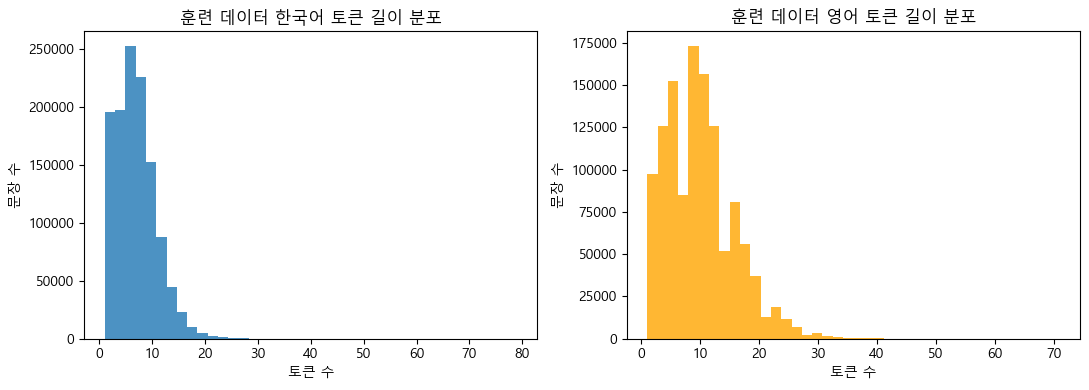


- train_pairs: 1,200,000, valid_pairs: 150,000


In [10]:
# STEP2_DATA_EDA
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import warnings

# 그래프 한글 폰트 설정 (Windows/Mac/Linux 공통 후보)
font_candidates = ["Malgun Gothic", "AppleGothic", "NanumGothic", "Noto Sans CJK KR", "Noto Sans KR"]
available_fonts = {f.name for f in fm.fontManager.ttflist}
selected_font = next((f for f in font_candidates if f in available_fonts), None)

if selected_font is not None:
    plt.rcParams["font.family"] = selected_font
    plt.rcParams["axes.unicode_minus"] = False
    print(f"[폰트 설정] 사용 폰트: {selected_font}")
else:
    # 폰트가 없으면 경고만 숨기고(로그 과다 방지), 라벨은 가능하면 영문 사용 권장
    warnings.filterwarnings("ignore", message="Glyph .* missing from font")
    print("[폰트 설정] 한글 폰트를 찾지 못했습니다. 필요 시 Malgun Gothic/NanumGothic 설치 권장")


def _load_json_records(path: Path):
    with path.open('r', encoding='utf-8') as f:
        obj = json.load(f)

    if isinstance(obj, list):
        records = obj
    elif isinstance(obj, dict):
        # dict 구조면 data 키를 우선 사용
        if 'data' in obj and isinstance(obj['data'], list):
            records = obj['data']
        else:
            # 그 외에는 list 타입 값을 찾아 사용
            records = None
            for v in obj.values():
                if isinstance(v, list):
                    records = v
                    break
            if records is None:
                raise ValueError(f'지원하지 않는 JSON 구조: {path}')
    else:
        raise ValueError(f'지원하지 않는 JSON 타입: {type(obj)} in {path}')

    df = pd.DataFrame(records)
    required_cols = {'ko', 'mt'}
    if not required_cols.issubset(df.columns):
        raise ValueError(f"필수 컬럼 {required_cols} 이(가) 없습니다. 현재 컬럼: {set(df.columns)}")

    return df[['ko', 'mt']].copy()

# 1) 데이터 경로 확인
train_path = Path(DATA_PATHS['train_json'])
valid_path = Path(DATA_PATHS['valid_json'])

if not train_path.exists() or not valid_path.exists():
    raise FileNotFoundError(
        '1단계 DATA_PATHS를 먼저 수정하세요. '
        f'train={train_path} exists={train_path.exists()}, '
        f'valid={valid_path} exists={valid_path.exists()}'
    )

# 2) 원본 데이터 로드
train_df_raw = _load_json_records(train_path)
valid_df_raw = _load_json_records(valid_path)

# 3) 기본 정제: 공백 제거 + 빈 문장 제거
def _clean_text_df(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy()
    out['ko'] = out['ko'].astype(str).str.strip()
    out['mt'] = out['mt'].astype(str).str.strip()
    out = out[(out['ko'] != '') & (out['mt'] != '')].reset_index(drop=True)
    return out

train_df = _clean_text_df(train_df_raw)
valid_df = _clean_text_df(valid_df_raw)

# 4) 문장 길이 통계(공백 기준 토큰 수)
train_df['ko_tok_len'] = train_df['ko'].str.split().str.len()
train_df['mt_tok_len'] = train_df['mt'].str.split().str.len()
valid_df['ko_tok_len'] = valid_df['ko'].str.split().str.len()
valid_df['mt_tok_len'] = valid_df['mt'].str.split().str.len()

def _describe_len(arr):
    arr = np.asarray(arr)
    return {
        'mean': float(arr.mean()),
        'median': float(np.median(arr)),
        'p95': float(np.percentile(arr, 95)),
        'p99': float(np.percentile(arr, 99)),
        'max': int(arr.max()),
    }

ko_stats = _describe_len(train_df['ko_tok_len'])
mt_stats = _describe_len(train_df['mt_tok_len'])

# 5) MAX_LENGTH 제안값 (p95 기반 + SOS/EOS 2칸)
suggested_max_len = int(max(ko_stats['p95'], mt_stats['p95']) + 2)
MAX_LENGTH = suggested_max_len
CFG['max_length'] = MAX_LENGTH

print('[2단계] 데이터 로드 + EDA 완료')
print(f"- 훈련 샘플 수 (원본 -> 정제): {len(train_df_raw):,} -> {len(train_df):,}")
print(f"- 검증 샘플 수 (원본 -> 정제): {len(valid_df_raw):,} -> {len(valid_df):,}")
print(f"- 제안 MAX_LENGTH (p95 기반): {MAX_LENGTH}")

print('\n[훈련 데이터 길이 통계 | 한국어]')
for k, v in ko_stats.items():
    print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")

print('\n[훈련 데이터 길이 통계 | 영어]')
for k, v in mt_stats.items():
    print(f"  {k}: {v:.2f}" if isinstance(v, float) else f"  {k}: {v}")

display(train_df[['ko', 'mt']].head(3))

# 길이 분포 시각화
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].hist(train_df['ko_tok_len'], bins=40, alpha=0.8)
axes[0].set_title('훈련 데이터 한국어 토큰 길이 분포')
axes[0].set_xlabel('토큰 수')
axes[0].set_ylabel('문장 수')

axes[1].hist(train_df['mt_tok_len'], bins=40, alpha=0.8, color='orange')
axes[1].set_title('훈련 데이터 영어 토큰 길이 분포')
axes[1].set_xlabel('토큰 수')
axes[1].set_ylabel('문장 수')

plt.tight_layout()
plt.show()

# 다음 단계에서 바로 사용할 문장쌍
train_pairs = list(zip(train_df['ko'].tolist(), train_df['mt'].tolist()))
valid_pairs = list(zip(valid_df['ko'].tolist(), valid_df['mt'].tolist()))
print(f"\n- train_pairs: {len(train_pairs):,}, valid_pairs: {len(valid_pairs):,}")


## 3. 데이터셋 소개 및 EDA 계획

- JSON 스키마 확인: 입력 `ko`, 정답 번역 `mt`
- 학습/검증 데이터 샘플 수 점검
- 한/영 문장 길이 분포 분석(평균, 중앙값, 상위 백분위)
- 결측/빈문장/극단적 길이(outlier) 처리 기준 정의
- EDA 결과를 바탕으로 `MAX_LENGTH` 근거 제시


In [11]:
# STEP3_DATASET_OVERVIEW
import pandas as pd
import numpy as np

# 2번 셀 선행 실행 확인
required_vars = ["train_df", "valid_df", "MAX_LENGTH", "train_pairs", "valid_pairs"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"2번 셀을 먼저 실행하세요. 누락 변수: {missing}")

# 1) 데이터셋 기본 요약
dataset_summary = pd.DataFrame([
    {
        "split": "train",
        "샘플수": len(train_df),
        "ko_평균길이": float(train_df["ko_tok_len"].mean()),
        "mt_평균길이": float(train_df["mt_tok_len"].mean()),
        "ko_p95": float(np.percentile(train_df["ko_tok_len"], 95)),
        "mt_p95": float(np.percentile(train_df["mt_tok_len"], 95)),
    },
    {
        "split": "valid",
        "샘플수": len(valid_df),
        "ko_평균길이": float(valid_df["ko_tok_len"].mean()),
        "mt_평균길이": float(valid_df["mt_tok_len"].mean()),
        "ko_p95": float(np.percentile(valid_df["ko_tok_len"], 95)),
        "mt_p95": float(np.percentile(valid_df["mt_tok_len"], 95)),
    },
])

print("[3단계] 데이터셋 소개/EDA 상세 점검 완료")
display(dataset_summary)

# 2) 길이 구간별 비율 확인(훈련셋 기준)
def _bucket_ratio(series):
    s = series.astype(int)
    total = len(s)
    buckets = {
        "<=10": (s <= 10).sum(),
        "11~20": ((s > 10) & (s <= 20)).sum(),
        "21~40": ((s > 20) & (s <= 40)).sum(),
        "41~80": ((s > 40) & (s <= 80)).sum(),
        "81~160": ((s > 80) & (s <= 160)).sum(),
        "161~320": ((s > 160) & (s <= 320)).sum(),
        ">320": (s > 320).sum(),
    }
    return {k: v / total for k, v in buckets.items()}

ko_bucket = _bucket_ratio(train_df["ko_tok_len"])
mt_bucket = _bucket_ratio(train_df["mt_tok_len"])

bucket_df = pd.DataFrame({
    "구간": list(ko_bucket.keys()),
    "ko_비율": [ko_bucket[k] for k in ko_bucket.keys()],
    "mt_비율": [mt_bucket[k] for k in mt_bucket.keys()],
})

print("\n[훈련 데이터 길이 구간 비율]")
display(bucket_df)

# 3) 긴 문장 샘플 확인(아웃라이어 점검)
long_ko_examples = train_df.nlargest(3, "ko_tok_len")[["ko", "mt", "ko_tok_len", "mt_tok_len"]]
long_mt_examples = train_df.nlargest(3, "mt_tok_len")[["ko", "mt", "ko_tok_len", "mt_tok_len"]]

print("\n[KO 기준 긴 문장 상위 3개]")
display(long_ko_examples)
print("\n[MT 기준 긴 문장 상위 3개]")
display(long_mt_examples)

# 4) MAX_LENGTH 커버리지 확인 (+2는 SOS/EOS 여유)
ko_coverage = ((train_df["ko_tok_len"] + 2) <= MAX_LENGTH).mean()
mt_coverage = ((train_df["mt_tok_len"] + 2) <= MAX_LENGTH).mean()

print("\n[MAX_LENGTH 커버리지 점검]")
print(f"- 현재 MAX_LENGTH: {MAX_LENGTH}")
print(f"- KO 커버리지: {ko_coverage*100:.2f}%")
print(f"- MT 커버리지: {mt_coverage*100:.2f}%")

# 5) 리포트용 요약 값 저장(이후 마크다운 분석에 활용)
EDA_REPORT = {
    "train_size": len(train_df),
    "valid_size": len(valid_df),
    "max_length": MAX_LENGTH,
    "ko_coverage": float(ko_coverage),
    "mt_coverage": float(mt_coverage),
}
print("\n- EDA_REPORT 저장 완료:", EDA_REPORT)


[3단계] 데이터셋 소개/EDA 상세 점검 완료


,split,샘플수,ko_평균길이,mt_평균길이,ko_p95,mt_p95
0,train,1200000,6.546667,9.857978,14.0,20.0
1,valid,150000,6.542620,9.850153,14.0,20.0



[훈련 데이터 길이 구간 비율]


,구간,ko_비율,mt_비율
0,<=10,0.853367,0.595078
1,11~20,0.142875,0.355091
2,21~40,0.003721,0.049517
3,41~80,0.000037,0.000313
4,81~160,0.000000,0.000000
5,161~320,0.000000,0.000000
6,>320,0.000000,0.000000



[KO 기준 긴 문장 상위 3개]


,ko,mt,ko_tok_len,mt_tok_len
856569,>(노래) 내 나이 열하고 아홉 살에 첫사랑에 잠 못 이루고 언제나 사랑한 건 두꺼...,>)))))) 나이 나이 나이 나이 나이 나이 나이 나ᄋ...,79,43
36153,이거를 이 상태로 하면 품질 관리가 절대 안 되겠다 그래 가지고 이제 업체 쪽에 좀...,"If we do this like this, we'll never be able t...",66,56
72585,아주 오래 전 옛날에 돼지고기를 키울 때 음식물이 나온 것도 먹였지만 화장실 옆에 ...,"A long time ago, when we raised pork, we fed t...",63,52



[MT 기준 긴 문장 상위 3개]


,ko,mt,ko_tok_len,mt_tok_len
1164651,컴퓨터 2대 사가지고 2명이서 창업한 회사고 그 당시에 5일 근무제 5일 수업제 이...,I bought two computers and started a company w...,51,71
1131591,모든 지구경을 위한 평생 구충제 맥스가드 스펙트라 당신의 마지막 모험은 언제였는가 ...,"Maxgard Spectra, a lifelong anthelmintic for a...",46,65
538681,>그날 저희가 번호 교환을 제가 먼저 물어봐서 번호를 제가 먼저 물어봐서 번호 교환...,">That day, we exchanged numbers first, so I as...",52,64



[MAX_LENGTH 커버리지 점검]
- 현재 MAX_LENGTH: 22
- KO 커버리지: 99.62%
- MT 커버리지: 95.02%

- EDA_REPORT 저장 완료: {'train_size': 1200000, 'valid_size': 150000, 'max_length': 22, 'ko_coverage': 0.9962416666666667, 'mt_coverage': 0.9501691666666666}


## 4. 전처리 및 토크나이징 전략

- 한국어/영어 각각에 맞는 정규화 규칙 정의
- 사용할 토크나이저와 선택 이유 기록
- 특수 토큰 정의: `SOS`, `EOS`, `PAD`, `UNK`
- 기본 전처리와 추가 전처리(선택 실험)를 분리해 관리


In [13]:
# STEP4_PREPROCESS_TOKENIZE
import re
import unicodedata
import numpy as np

# 2번 셀 선행 실행 확인
required_vars = ["train_df", "valid_df", "MAX_LENGTH"]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"2번 셀을 먼저 실행하세요. 누락 변수: {missing}")

# 특수 토큰 정의(이후 5~7번 단계에서 재사용)
SPECIAL_TOKENS = {
    "PAD": "<pad>",
    "SOS": "<sos>",
    "EOS": "<eos>",
    "UNK": "<unk>",
}

TOKENIZER_INFO = {
    "ko": "공백 기반 + 기본 정규화",
    "en": "소문자 + 공백 기반 + 기본 정규화",
}

def normalize_ko_text(text: str) -> str:
    text = unicodedata.normalize("NFKC", str(text))
    text = text.strip()
    # 너무 특수한 기호 제거(한글/영문/숫자/기본 문장부호만 유지)
    text = re.sub(r"[^가-힣a-zA-Z0-9\s\.,!;:\-]", " ", text)
    # 문장부호 주변 공백 정리
    text = re.sub(r"([\.,!;:])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def normalize_en_text(text: str) -> str:
    text = unicodedata.normalize("NFKC", str(text))
    text = text.lower().strip()
    text = re.sub(r"[^a-z0-9\s\.,!;:\-]", " ", text)
    text = re.sub(r"([\.,!;:])", r" \1 ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

def tokenize_ko(text: str):
    return normalize_ko_text(text).split()

def tokenize_en(text: str):
    return normalize_en_text(text).split()

# 정규화 텍스트 컬럼 추가
train_df["ko_norm"] = train_df["ko"].apply(normalize_ko_text)
train_df["mt_norm"] = train_df["mt"].apply(normalize_en_text)
valid_df["ko_norm"] = valid_df["ko"].apply(normalize_ko_text)
valid_df["mt_norm"] = valid_df["mt"].apply(normalize_en_text)

# 토큰화
train_src_tokens = train_df["ko_norm"].apply(tokenize_ko).tolist()
train_tgt_tokens = train_df["mt_norm"].apply(tokenize_en).tolist()
valid_src_tokens = valid_df["ko_norm"].apply(tokenize_ko).tolist()
valid_tgt_tokens = valid_df["mt_norm"].apply(tokenize_en).tolist()

# 토큰 길이 통계
train_src_lens = np.array([len(x) for x in train_src_tokens])
train_tgt_lens = np.array([len(x) for x in train_tgt_tokens])

MAX_SRC_LEN = int(np.percentile(train_src_lens, 95)) + 2  # SOS/EOS 여유
MAX_TGT_LEN = int(np.percentile(train_tgt_lens, 95)) + 2  # SOS/EOS 여유

# 기존 MAX_LENGTH와 일관성 유지 (더 보수적인 값 채택)
MAX_LENGTH = max(MAX_LENGTH, MAX_SRC_LEN, MAX_TGT_LEN)
CFG["max_length"] = MAX_LENGTH
CFG["max_src_len"] = MAX_SRC_LEN
CFG["max_tgt_len"] = MAX_TGT_LEN

# 길이 커버리지 점검
src_coverage = ((train_src_lens + 2) <= MAX_LENGTH).mean()
tgt_coverage = ((train_tgt_lens + 2) <= MAX_LENGTH).mean()

print("[4단계] 전처리/토크나이징 완료")
print(f"- 토크나이저(ko): {TOKENIZER_INFO['ko']}")
print(f"- 토크나이저(en): {TOKENIZER_INFO['en']}")
print(f"- MAX_SRC_LEN(p95+2): {MAX_SRC_LEN}")
print(f"- MAX_TGT_LEN(p95+2): {MAX_TGT_LEN}")
print(f"- 최종 MAX_LENGTH: {MAX_LENGTH}")
print(f"- SRC 커버리지: {src_coverage*100:.2f}%")
print(f"- TGT 커버리지: {tgt_coverage*100:.2f}%")

print("\n[토큰화 예시 2개]")
for i in range(2):
    print(f"- 원문 KO: {train_df.iloc[i]['ko']}")
    print(f"  토큰 KO: {train_src_tokens[i][:20]}")
    print(f"  원문 EN: {train_df.iloc[i]['mt']}")
    print(f"  토큰 EN: {train_tgt_tokens[i][:20]}")

# 이후 단계(5~7번)에서 사용할 튜플 형태 유지
train_token_pairs = list(zip(train_src_tokens, train_tgt_tokens))
valid_token_pairs = list(zip(valid_src_tokens, valid_tgt_tokens))
print(f"\n- train_token_pairs: {len(train_token_pairs):,}")
print(f"- valid_token_pairs: {len(valid_token_pairs):,}")


[4단계] 전처리/토크나이징 완료
- 토크나이저(ko): 공백 기반 + 기본 정규화
- 토크나이저(en): 소문자 + 공백 기반 + 기본 정규화
- MAX_SRC_LEN(p95+2): 17
- MAX_TGT_LEN(p95+2): 25
- 최종 MAX_LENGTH: 25
- SRC 커버리지: 99.69%
- TGT 커버리지: 95.55%

[토큰화 예시 2개]
- 원문 KO: 원하시는 색상을 회신해 주시면 바로 제작 들어가겠습니다.
  토큰 KO: ['원하시는', '색상을', '회신해', '주시면', '바로', '제작', '들어가겠습니다', '.']
  원문 EN: If you reply to the color you want, we will start making it right away.
  토큰 EN: ['if', 'you', 'reply', 'to', 'the', 'color', 'you', 'want', ',', 'we', 'will', 'start', 'making', 'it', 'right', 'away', '.']
- 원문 KO: 형님 제일 웃긴 그림이 뭔지 알아요.
  토큰 KO: ['형님', '제일', '웃긴', '그림이', '뭔지', '알아요', '.']
  원문 EN: I know what the funniest picture is.
  토큰 EN: ['i', 'know', 'what', 'the', 'funniest', 'picture', 'is', '.']

- train_token_pairs: 1,200,000
- valid_token_pairs: 150,000


## 5. 어휘 사전(Vocab) 구축 전략

- 한국어/영어 어휘 사전을 분리하여 구축
- `token2idx`, `idx2token` 매핑 규칙 정의
- 최소 등장 빈도(min frequency) 기준 사용 여부 명시
- UNK 처리 정책과 최종 vocab 크기 보고


In [14]:
# STEP5_VOCAB_BUILD
from collections import Counter
import pandas as pd

# 4번 셀 선행 실행 확인
required_vars = [
    "train_src_tokens", "train_tgt_tokens",
    "valid_src_tokens", "valid_tgt_tokens",
    "SPECIAL_TOKENS"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"4번 셀을 먼저 실행하세요. 누락 변수: {missing}")

# 최소 빈도(희소 토큰 제거 기준)
SRC_MIN_FREQ = 2
TGT_MIN_FREQ = 2
CFG["src_min_freq"] = SRC_MIN_FREQ
CFG["tgt_min_freq"] = TGT_MIN_FREQ

# 특수 토큰 인덱스 고정 (패딩/시작/끝/미등록)
SPECIAL_ORDER = [
    SPECIAL_TOKENS["PAD"],
    SPECIAL_TOKENS["SOS"],
    SPECIAL_TOKENS["EOS"],
    SPECIAL_TOKENS["UNK"],
]

PAD_IDX = 0
SOS_IDX = 1
EOS_IDX = 2
UNK_IDX = 3

def build_vocab(token_lists, min_freq=1):
    counter = Counter(tok for sent in token_lists for tok in sent)
    vocab_tokens = [tok for tok, cnt in counter.items() if cnt >= min_freq]
    # 재현성을 위해 정렬
    vocab_tokens = sorted(vocab_tokens)

    token2idx = {tok: i for i, tok in enumerate(SPECIAL_ORDER)}
    for tok in vocab_tokens:
        if tok not in token2idx:
            token2idx[tok] = len(token2idx)

    idx2token = {idx: tok for tok, idx in token2idx.items()}
    return token2idx, idx2token, counter

# 학습셋 기준으로 vocab 구축
src_token2idx, src_idx2token, src_counter = build_vocab(train_src_tokens, min_freq=SRC_MIN_FREQ)
tgt_token2idx, tgt_idx2token, tgt_counter = build_vocab(train_tgt_tokens, min_freq=TGT_MIN_FREQ)

# 검증셋 OOV 비율 점검
def oov_ratio(token_lists, token2idx):
    total = 0
    oov = 0
    for sent in token_lists:
        for tok in sent:
            total += 1
            if tok not in token2idx:
                oov += 1
    return (oov / total) if total > 0 else 0.0

src_valid_oov = oov_ratio(valid_src_tokens, src_token2idx)
tgt_valid_oov = oov_ratio(valid_tgt_tokens, tgt_token2idx)

CFG["src_vocab_size"] = len(src_token2idx)
CFG["tgt_vocab_size"] = len(tgt_token2idx)
CFG["pad_idx"] = PAD_IDX
CFG["sos_idx"] = SOS_IDX
CFG["eos_idx"] = EOS_IDX
CFG["unk_idx"] = UNK_IDX

print("[5단계] 어휘 사전 구축 완료")
print(f"- SRC vocab 크기: {len(src_token2idx):,} (min_freq={SRC_MIN_FREQ})")
print(f"- TGT vocab 크기: {len(tgt_token2idx):,} (min_freq={TGT_MIN_FREQ})")
print(f"- PAD/SOS/EOS/UNK 인덱스: {PAD_IDX}/{SOS_IDX}/{EOS_IDX}/{UNK_IDX}")
print(f"- 검증셋 SRC OOV 비율: {src_valid_oov*100:.2f}%")
print(f"- 검증셋 TGT OOV 비율: {tgt_valid_oov*100:.2f}%")

# 자주 등장하는 토큰 상위 20개 확인
src_top20 = src_counter.most_common(20)
tgt_top20 = tgt_counter.most_common(20)
display(pd.DataFrame(src_top20, columns=["src_token", "count"]))
display(pd.DataFrame(tgt_top20, columns=["tgt_token", "count"]))


[5단계] 어휘 사전 구축 완료
- SRC vocab 크기: 237,987 (min_freq=2)
- TGT vocab 크기: 40,333 (min_freq=2)
- PAD/SOS/EOS/UNK 인덱스: 0/1/2/3
- 검증셋 SRC OOV 비율: 4.80%
- 검증셋 TGT OOV 비율: 0.31%


,src_token,count
0,.,1059494
1,",",282225
2,수,102008
3,있습니다,98650
4,저희,43144
5,이,42025
6,있는,33433
7,네,32454
8,합니다,27194
9,더,26939


,tgt_token,count
0,.,1087423
1,",",556980
2,the,533801
3,to,346033
4,you,326205
5,i,301311
6,it,282017
7,a,280140
8,and,234783
9,is,208905


## 6. 시퀀스 인코딩 및 패딩 규칙

- 토큰 시퀀스를 인덱스 시퀀스로 변환
- 디코더 입력/타깃에 `SOS/EOS`를 일관되게 적용
- `MAX_LENGTH` 기준으로 padding/truncation 수행
- 학습 시 타깃 정렬(shift) 방식 명확히 문서화


In [15]:
# STEP6_SEQUENCE_ENCODING
import numpy as np

# 4,5번 셀 선행 실행 확인
required_vars = [
    "train_src_tokens", "train_tgt_tokens", "valid_src_tokens", "valid_tgt_tokens",
    "src_token2idx", "tgt_token2idx", "src_idx2token", "tgt_idx2token",
    "MAX_SRC_LEN", "MAX_TGT_LEN"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"4번/5번 셀을 먼저 실행하세요. 누락 변수: {missing}")

# 인덱스(5번에서 정의된 값 우선 사용)
PAD_IDX = globals().get("PAD_IDX", CFG.get("pad_idx", 0))
SOS_IDX = globals().get("SOS_IDX", CFG.get("sos_idx", 1))
EOS_IDX = globals().get("EOS_IDX", CFG.get("eos_idx", 2))
UNK_IDX = globals().get("UNK_IDX", CFG.get("unk_idx", 3))

def _pad_to_len(ids, max_len, pad_idx=0):
    if len(ids) >= max_len:
        return ids[:max_len]
    return ids + [pad_idx] * (max_len - len(ids))

def encode_src(tokens, token2idx, max_len):
    # SRC는 [tokens ... EOS] 형태로 구성
    ids = [token2idx.get(tok, UNK_IDX) for tok in tokens]
    truncated = False
    if len(ids) > max_len - 1:
        ids = ids[: max_len - 1]
        truncated = True
    ids = ids + [EOS_IDX]
    seq_len = len(ids)
    ids = _pad_to_len(ids, max_len, PAD_IDX)
    return ids, seq_len, truncated

def encode_tgt(tokens, token2idx, max_len):
    # decoder 입력: [SOS ...tokens]
    # decoder 출력(정답): [...tokens EOS]
    core = [token2idx.get(tok, UNK_IDX) for tok in tokens]
    truncated = False
    if len(core) > max_len - 1:
        core = core[: max_len - 1]
        truncated = True

    tgt_in = [SOS_IDX] + core
    tgt_out = core + [EOS_IDX]

    seq_len = len(tgt_out)  # EOS 포함 길이
    tgt_in = _pad_to_len(tgt_in, max_len, PAD_IDX)
    tgt_out = _pad_to_len(tgt_out, max_len, PAD_IDX)
    return tgt_in, tgt_out, seq_len, truncated

def build_encoded_split(src_tokens_list, tgt_tokens_list):
    src_ids_all, tgt_in_all, tgt_out_all = [], [], []
    src_lens, tgt_lens = [], []
    src_trunc_count, tgt_trunc_count = 0, 0

    for src_toks, tgt_toks in zip(src_tokens_list, tgt_tokens_list):
        src_ids, src_len, src_trunc = encode_src(src_toks, src_token2idx, MAX_SRC_LEN)
        tgt_in, tgt_out, tgt_len, tgt_trunc = encode_tgt(tgt_toks, tgt_token2idx, MAX_TGT_LEN)

        src_ids_all.append(src_ids)
        tgt_in_all.append(tgt_in)
        tgt_out_all.append(tgt_out)
        src_lens.append(src_len)
        tgt_lens.append(tgt_len)
        src_trunc_count += int(src_trunc)
        tgt_trunc_count += int(tgt_trunc)

    return {
        "src_ids": src_ids_all,
        "tgt_in_ids": tgt_in_all,
        "tgt_out_ids": tgt_out_all,
        "src_lens": src_lens,
        "tgt_lens": tgt_lens,
        "src_trunc_count": src_trunc_count,
        "tgt_trunc_count": tgt_trunc_count,
    }

# split별 인코딩 실행
train_encoded = build_encoded_split(train_src_tokens, train_tgt_tokens)
valid_encoded = build_encoded_split(valid_src_tokens, valid_tgt_tokens)

# 다음 단계(7번)에서 바로 사용할 변수명
train_src_ids = train_encoded["src_ids"]
train_tgt_in_ids = train_encoded["tgt_in_ids"]
train_tgt_out_ids = train_encoded["tgt_out_ids"]
train_src_lens = train_encoded["src_lens"]
train_tgt_lens = train_encoded["tgt_lens"]

valid_src_ids = valid_encoded["src_ids"]
valid_tgt_in_ids = valid_encoded["tgt_in_ids"]
valid_tgt_out_ids = valid_encoded["tgt_out_ids"]
valid_src_lens = valid_encoded["src_lens"]
valid_tgt_lens = valid_encoded["tgt_lens"]

train_encoded_samples = list(zip(train_src_ids, train_tgt_in_ids, train_tgt_out_ids, train_src_lens, train_tgt_lens))
valid_encoded_samples = list(zip(valid_src_ids, valid_tgt_in_ids, valid_tgt_out_ids, valid_src_lens, valid_tgt_lens))

# 인코딩 결과 요약
src_trunc_rate = train_encoded["src_trunc_count"] / max(1, len(train_src_ids))
tgt_trunc_rate = train_encoded["tgt_trunc_count"] / max(1, len(train_tgt_in_ids))

CFG["max_src_len"] = MAX_SRC_LEN
CFG["max_tgt_len"] = MAX_TGT_LEN
CFG["src_trunc_rate"] = float(src_trunc_rate)
CFG["tgt_trunc_rate"] = float(tgt_trunc_rate)

print("[6단계] 시퀀스 인코딩/패딩 완료")
print(f"- MAX_SRC_LEN: {MAX_SRC_LEN}, MAX_TGT_LEN: {MAX_TGT_LEN}")
print(f"- train 샘플 수: {len(train_encoded_samples):,}")
print(f"- valid 샘플 수: {len(valid_encoded_samples):,}")
print(f"- SRC 절단 비율: {src_trunc_rate*100:.2f}%")
print(f"- TGT 절단 비율: {tgt_trunc_rate*100:.2f}%")

print("\n[인코딩 샘플 shape 확인]")
print(f"- src ids 길이: {len(train_src_ids[0])}")
print(f"- tgt_in ids 길이: {len(train_tgt_in_ids[0])}")
print(f"- tgt_out ids 길이: {len(train_tgt_out_ids[0])}")

def quick_decode(ids, idx2token, stop_at_eos=True):
    toks = []
    for idx in ids:
        if idx == PAD_IDX:
            continue
        if idx == SOS_IDX:
            continue
        if stop_at_eos and idx == EOS_IDX:
            break
        toks.append(idx2token.get(idx, SPECIAL_TOKENS["UNK"]))
    return toks

print("\n[디코딩 확인 예시 1개]")
print("- SRC:", quick_decode(train_src_ids[0], src_idx2token))
print("- TGT_IN:", quick_decode(train_tgt_in_ids[0], tgt_idx2token))
print("- TGT_OUT:", quick_decode(train_tgt_out_ids[0], tgt_idx2token))


[6단계] 시퀀스 인코딩/패딩 완료
- MAX_SRC_LEN: 17, MAX_TGT_LEN: 25
- train 샘플 수: 1,200,000
- valid 샘플 수: 150,000
- SRC 절단 비율: 3.12%
- TGT 절단 비율: 3.58%

[인코딩 샘플 shape 확인]
- src ids 길이: 17
- tgt_in ids 길이: 25
- tgt_out ids 길이: 25

[디코딩 확인 예시 1개]
- SRC: ['원하시는', '색상을', '회신해', '주시면', '바로', '제작', '들어가겠습니다', '.']
- TGT_IN: ['if', 'you', 'reply', 'to', 'the', 'color', 'you', 'want', ',', 'we', 'will', 'start', 'making', 'it', 'right', 'away', '.']
- TGT_OUT: ['if', 'you', 'reply', 'to', 'the', 'color', 'you', 'want', ',', 'we', 'will', 'start', 'making', 'it', 'right', 'away', '.']


## 7. Dataset/DataLoader 설계

- 학습에 필요한 텐서(encoder input, decoder target) 구성
- `DataLoader`로 미니배치 학습 파이프라인 구성
- 배치 shape를 sanity check로 검증
- 두 모델에 동일한 데이터 입력 파이프라인 적용


In [16]:
# STEP7_DATASET_DATALOADER
import torch
from torch.utils.data import Dataset, DataLoader

# 6번 셀 선행 실행 확인
required_vars = [
    "train_src_ids", "train_tgt_in_ids", "train_tgt_out_ids", "train_src_lens", "train_tgt_lens",
    "valid_src_ids", "valid_tgt_in_ids", "valid_tgt_out_ids", "valid_src_lens", "valid_tgt_lens",
    "PAD_IDX", "CFG"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"6번 셀을 먼저 실행하세요. 누락 변수: {missing}")

# 배치 크기(1번 설정 우선)
BATCH_SIZE = int(CFG.get("batch_size", 64))
CFG["batch_size"] = BATCH_SIZE

class TranslationDataset(Dataset):
    """
    각 샘플 구성:
    - src_ids: 인코더 입력
    - tgt_in_ids: 디코더 입력(SOS 포함)
    - tgt_out_ids: 디코더 정답(EOS 포함)
    - src_len, tgt_len: 실제 길이(패딩 제외)
    """
    def __init__(self, src_ids, tgt_in_ids, tgt_out_ids, src_lens, tgt_lens):
        self.src_ids = src_ids
        self.tgt_in_ids = tgt_in_ids
        self.tgt_out_ids = tgt_out_ids
        self.src_lens = src_lens
        self.tgt_lens = tgt_lens

    def __len__(self):
        return len(self.src_ids)

    def __getitem__(self, idx):
        return {
            "src_ids": torch.tensor(self.src_ids[idx], dtype=torch.long),
            "tgt_in_ids": torch.tensor(self.tgt_in_ids[idx], dtype=torch.long),
            "tgt_out_ids": torch.tensor(self.tgt_out_ids[idx], dtype=torch.long),
            "src_len": torch.tensor(self.src_lens[idx], dtype=torch.long),
            "tgt_len": torch.tensor(self.tgt_lens[idx], dtype=torch.long),
        }

def collate_batch(batch):
    """
    현재 6번에서 이미 고정 길이 패딩을 했으므로,
    여기서는 텐서 스택과 마스크 생성만 수행.
    """
    src_ids = torch.stack([b["src_ids"] for b in batch], dim=0)
    tgt_in_ids = torch.stack([b["tgt_in_ids"] for b in batch], dim=0)
    tgt_out_ids = torch.stack([b["tgt_out_ids"] for b in batch], dim=0)
    src_lens = torch.stack([b["src_len"] for b in batch], dim=0)
    tgt_lens = torch.stack([b["tgt_len"] for b in batch], dim=0)

    # 패딩 마스크(True=패딩 위치)
    src_pad_mask = (src_ids == PAD_IDX)
    tgt_pad_mask = (tgt_in_ids == PAD_IDX)

    return {
        "src_ids": src_ids,
        "tgt_in_ids": tgt_in_ids,
        "tgt_out_ids": tgt_out_ids,
        "src_lens": src_lens,
        "tgt_lens": tgt_lens,
        "src_pad_mask": src_pad_mask,
        "tgt_pad_mask": tgt_pad_mask,
    }

# Dataset 생성
train_dataset = TranslationDataset(
    train_src_ids, train_tgt_in_ids, train_tgt_out_ids, train_src_lens, train_tgt_lens
)
valid_dataset = TranslationDataset(
    valid_src_ids, valid_tgt_in_ids, valid_tgt_out_ids, valid_src_lens, valid_tgt_lens
)

# DataLoader 생성
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    collate_fn=collate_batch,
)
valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    collate_fn=collate_batch,
)

# sanity check
batch = next(iter(train_loader))
print("[7단계] Dataset/DataLoader 구성 완료")
print(f"- train dataset 크기: {len(train_dataset):,}")
print(f"- valid dataset 크기: {len(valid_dataset):,}")
print(f"- batch size: {BATCH_SIZE}")
print("\n[배치 텐서 shape]")
print(f"- src_ids: {tuple(batch['src_ids'].shape)}")
print(f"- tgt_in_ids: {tuple(batch['tgt_in_ids'].shape)}")
print(f"- tgt_out_ids: {tuple(batch['tgt_out_ids'].shape)}")
print(f"- src_pad_mask: {tuple(batch['src_pad_mask'].shape)}")
print(f"- tgt_pad_mask: {tuple(batch['tgt_pad_mask'].shape)}")

# 이후 학습 단계(8~10)에서 사용할 키 변수 명시
CFG["train_size"] = len(train_dataset)
CFG["valid_size"] = len(valid_dataset)
print("\n- 학습 단계 연결 변수: train_loader, valid_loader")


[7단계] Dataset/DataLoader 구성 완료
- train dataset 크기: 1,200,000
- valid dataset 크기: 150,000
- batch size: 64

[배치 텐서 shape]
- src_ids: (64, 17)
- tgt_in_ids: (64, 25)
- tgt_out_ids: (64, 25)
- src_pad_mask: (64, 17)
- tgt_pad_mask: (64, 25)

- 학습 단계 연결 변수: train_loader, valid_loader


## 8. 모델 A: Seq2Seq (GRU)

- Encoder-Decoder 기본 구조 설명
- Encoder hidden state가 Decoder로 전달되는 흐름 설명
- Teacher Forcing 적용 방식과 비율 기록
- epoch별 train/valid 로그 출력 규칙 정의


In [18]:
# STEP8_SEQ2SEQ_GRU_MODEL
import random
import torch
import torch.nn as nn

# 7번까지 선행 실행 확인
required_vars = [
    "src_token2idx", "tgt_token2idx",
    "src_idx2token", "tgt_idx2token",
    "PAD_IDX", "SOS_IDX", "EOS_IDX",
    "train_loader", "device", "CFG"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"1~7번 셀을 먼저 실행하세요. 누락 변수: {missing}")

SRC_VOCAB_SIZE = len(src_token2idx)
TGT_VOCAB_SIZE = len(tgt_token2idx)

# 모델 A 하이퍼파라미터
SEQ2SEQ_CFG = {
    "embedding_dim": 256,
    "hidden_dim": 256,
    "num_layers": 1,
    "dropout": 0.2,
}
CFG["seq2seq_gru"] = SEQ2SEQ_CFG

class EncoderGRU(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.0, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

    def forward(self, src_ids):
        # src_ids: [B, src_len]
        emb = self.embedding(src_ids)  # [B, src_len, emb_dim]
        _, hidden = self.gru(emb)      # hidden: [num_layers, B, hidden_dim]
        return hidden


class DecoderGRU(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.0, pad_idx=0):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc_out = nn.Linear(hidden_dim, vocab_size)

    def forward(self, token_ids, hidden):
        # token_ids: [B]
        emb = self.embedding(token_ids).unsqueeze(1)  # [B, 1, emb_dim]
        out, hidden = self.gru(emb, hidden)           # out: [B, 1, hidden]
        logits = self.fc_out(out.squeeze(1))          # [B, vocab_size]
        return logits, hidden


class Seq2SeqGRU(nn.Module):
    def __init__(self, encoder, decoder, pad_idx=0):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder
        self.pad_idx = pad_idx

    def forward(self, src_ids, tgt_in_ids, teacher_forcing_ratio=0.5):
        # src_ids: [B, src_len], tgt_in_ids: [B, tgt_len]
        batch_size = src_ids.size(0)
        tgt_len = tgt_in_ids.size(1)
        vocab_size = self.decoder.vocab_size

        outputs = torch.zeros(batch_size, tgt_len, vocab_size, device=src_ids.device)
        hidden = self.encoder(src_ids)

        # 디코더 시작 토큰: tgt_in의 첫 토큰(SOS)
        dec_input = tgt_in_ids[:, 0]

        for t in range(tgt_len):
            logits, hidden = self.decoder(dec_input, hidden)
            outputs[:, t, :] = logits

            if t + 1 < tgt_len:
                use_teacher = random.random() < teacher_forcing_ratio
                pred_token = logits.argmax(dim=1)
                dec_input = tgt_in_ids[:, t + 1] if use_teacher else pred_token

        return outputs


def greedy_decode_seq2seq(model, src_ids, max_tgt_len, sos_idx, eos_idx):
    """src_ids: [1, src_len] 텐서 입력, 출력은 토큰 인덱스 리스트"""
    model.eval()
    with torch.no_grad():
        hidden = model.encoder(src_ids)
        dec_input = torch.tensor([sos_idx], device=src_ids.device)
        generated = []

        for _ in range(max_tgt_len):
            logits, hidden = model.decoder(dec_input, hidden)
            next_token = int(logits.argmax(dim=1).item())
            if next_token == eos_idx:
                break
            generated.append(next_token)
            dec_input = torch.tensor([next_token], device=src_ids.device)

    return generated


# 모델 생성
encoder_gru = EncoderGRU(
    vocab_size=SRC_VOCAB_SIZE,
    emb_dim=SEQ2SEQ_CFG["embedding_dim"],
    hidden_dim=SEQ2SEQ_CFG["hidden_dim"],
    num_layers=SEQ2SEQ_CFG["num_layers"],
    dropout=SEQ2SEQ_CFG["dropout"],
    pad_idx=PAD_IDX,
)
decoder_gru = DecoderGRU(
    vocab_size=TGT_VOCAB_SIZE,
    emb_dim=SEQ2SEQ_CFG["embedding_dim"],
    hidden_dim=SEQ2SEQ_CFG["hidden_dim"],
    num_layers=SEQ2SEQ_CFG["num_layers"],
    dropout=SEQ2SEQ_CFG["dropout"],
    pad_idx=PAD_IDX,
)
model_seq2seq = Seq2SeqGRU(encoder_gru, decoder_gru, pad_idx=PAD_IDX).to(device)

# 손실 함수(패딩 토큰 무시)
criterion_seq2seq = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# sanity check: 배치 1개 forward
sample_batch = next(iter(train_loader))
src_ids = sample_batch["src_ids"].to(device)
tgt_in_ids = sample_batch["tgt_in_ids"].to(device)
tgt_out_ids = sample_batch["tgt_out_ids"].to(device)

logits = model_seq2seq(src_ids, tgt_in_ids, teacher_forcing_ratio=0.0)
loss = criterion_seq2seq(logits.reshape(-1, logits.size(-1)), tgt_out_ids.reshape(-1))

print("[8단계] Seq2Seq(GRU) 모델 정의 완료")
print(f"- SRC vocab: {SRC_VOCAB_SIZE:,}, TGT vocab: {TGT_VOCAB_SIZE:,}")
print(f"- logits shape: {tuple(logits.shape)}")
print(f"- sanity loss: {float(loss.item()):.4f}")

# 이후 단계에서 공통 참조할 수 있도록 등록
if "MODELS" not in globals():
    MODELS = {}
MODELS["seq2seq_gru"] = model_seq2seq
print("- 등록 완료: MODELS['seq2seq_gru']")


[8단계] Seq2Seq(GRU) 모델 정의 완료
- SRC vocab: 237,987, TGT vocab: 40,333
- logits shape: (64, 25, 40333)
- sanity loss: 10.6257
- 등록 완료: MODELS['seq2seq_gru']


## 9. 모델 B: Seq2Seq with Attention

- Attention(Bahdanau 또는 Luong) 메커니즘을 Decoder에 적용
- context vector 계산 및 결합 방식 설명
- 모델 A와 동일한 조건에서 학습하여 공정 비교


In [20]:
# STEP9_SEQ2SEQ_ATTENTION_MODEL
import random
import torch
import torch.nn as nn
import torch.nn.functional as F

# 1~8번 선행 실행 확인
required_vars = [
    "src_token2idx", "tgt_token2idx",
    "PAD_IDX", "SOS_IDX", "EOS_IDX",
    "train_loader", "device", "CFG"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"1~8번 셀을 먼저 실행하세요. 누락 변수: {missing}")

SRC_VOCAB_SIZE = len(src_token2idx)
TGT_VOCAB_SIZE = len(tgt_token2idx)

# 모델 B 하이퍼파라미터(8번과 동일한 기본 크기 유지)
ATTN_CFG = {
    "embedding_dim": 256,
    "hidden_dim": 256,
    "num_layers": 1,
    "dropout": 0.2,
}
CFG["seq2seq_attention"] = ATTN_CFG


class EncoderGRUForAttention(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, num_layers=1, dropout=0.0, pad_idx=0):
        super().__init__()
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.gru = nn.GRU(
            input_size=emb_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )

    def forward(self, src_ids):
        # src_ids: [B, src_len]
        emb = self.embedding(src_ids)                  # [B, src_len, emb_dim]
        enc_outputs, hidden = self.gru(emb)           # [B, src_len, H], [L, B, H]
        return enc_outputs, hidden


class BahdanauAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.W_h = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.W_s = nn.Linear(hidden_dim, hidden_dim, bias=False)
        self.v = nn.Linear(hidden_dim, 1, bias=False)

    def forward(self, decoder_hidden_last, encoder_outputs, src_pad_mask=None):
        # decoder_hidden_last: [B, H]
        # encoder_outputs: [B, src_len, H]
        src_len = encoder_outputs.size(1)
        dec_proj = self.W_s(decoder_hidden_last).unsqueeze(1).repeat(1, src_len, 1)
        enc_proj = self.W_h(encoder_outputs)
        energy = torch.tanh(enc_proj + dec_proj)      # [B, src_len, H]
        scores = self.v(energy).squeeze(-1)           # [B, src_len]

        if src_pad_mask is not None:
            # pad 위치는 매우 작은 값으로 마스킹
            scores = scores.masked_fill(src_pad_mask, -1e9)

        attn_weights = F.softmax(scores, dim=1)       # [B, src_len]
        context = torch.bmm(attn_weights.unsqueeze(1), encoder_outputs).squeeze(1)  # [B, H]
        return context, attn_weights


class AttentionDecoderGRU(nn.Module):
    def __init__(self, vocab_size, emb_dim, hidden_dim, attention, num_layers=1, dropout=0.0, pad_idx=0):
        super().__init__()
        self.vocab_size = vocab_size
        self.embedding = nn.Embedding(vocab_size, emb_dim, padding_idx=pad_idx)
        self.attention = attention
        self.gru = nn.GRU(
            input_size=emb_dim + hidden_dim,  # 토큰 임베딩 + context
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            dropout=dropout if num_layers > 1 else 0.0,
        )
        self.fc_out = nn.Linear(hidden_dim * 2, vocab_size)

    def forward(self, token_ids, hidden, encoder_outputs, src_pad_mask=None):
        # token_ids: [B]
        emb = self.embedding(token_ids).unsqueeze(1)  # [B, 1, emb_dim]
        dec_last = hidden[-1]                         # [B, H]
        context, attn_weights = self.attention(dec_last, encoder_outputs, src_pad_mask)
        rnn_input = torch.cat([emb, context.unsqueeze(1)], dim=-1)  # [B,1,emb+H]

        out, hidden = self.gru(rnn_input, hidden)     # out: [B,1,H]
        out = out.squeeze(1)                           # [B,H]
        logits = self.fc_out(torch.cat([out, context], dim=-1))     # [B,V]
        return logits, hidden, attn_weights


class Seq2SeqAttention(nn.Module):
    def __init__(self, encoder, decoder):
        super().__init__()
        self.encoder = encoder
        self.decoder = decoder

    def forward(self, src_ids, tgt_in_ids, src_pad_mask=None, teacher_forcing_ratio=0.5):
        batch_size = src_ids.size(0)
        tgt_len = tgt_in_ids.size(1)
        vocab_size = self.decoder.vocab_size
        src_len = src_ids.size(1)

        outputs = torch.zeros(batch_size, tgt_len, vocab_size, device=src_ids.device)
        all_attn = torch.zeros(batch_size, tgt_len, src_len, device=src_ids.device)

        enc_outputs, hidden = self.encoder(src_ids)
        dec_input = tgt_in_ids[:, 0]  # SOS

        for t in range(tgt_len):
            logits, hidden, attn = self.decoder(dec_input, hidden, enc_outputs, src_pad_mask)
            outputs[:, t, :] = logits
            all_attn[:, t, :] = attn

            if t + 1 < tgt_len:
                use_teacher = random.random() < teacher_forcing_ratio
                pred_token = logits.argmax(dim=1)
                dec_input = tgt_in_ids[:, t + 1] if use_teacher else pred_token

        return outputs, all_attn


def greedy_decode_attention(model, src_ids, src_pad_mask, max_tgt_len, sos_idx, eos_idx):
    model.eval()
    with torch.no_grad():
        enc_outputs, hidden = model.encoder(src_ids)
        dec_input = torch.tensor([sos_idx], device=src_ids.device)
        generated = []
        attn_trace = []

        for _ in range(max_tgt_len):
            logits, hidden, attn = model.decoder(dec_input, hidden, enc_outputs, src_pad_mask)
            next_token = int(logits.argmax(dim=1).item())
            attn_trace.append(attn.squeeze(0).cpu())
            if next_token == eos_idx:
                break
            generated.append(next_token)
            dec_input = torch.tensor([next_token], device=src_ids.device)

    return generated, attn_trace


# 모델 생성
encoder_attn = EncoderGRUForAttention(
    vocab_size=SRC_VOCAB_SIZE,
    emb_dim=ATTN_CFG["embedding_dim"],
    hidden_dim=ATTN_CFG["hidden_dim"],
    num_layers=ATTN_CFG["num_layers"],
    dropout=ATTN_CFG["dropout"],
    pad_idx=PAD_IDX,
)
attention = BahdanauAttention(hidden_dim=ATTN_CFG["hidden_dim"])
decoder_attn = AttentionDecoderGRU(
    vocab_size=TGT_VOCAB_SIZE,
    emb_dim=ATTN_CFG["embedding_dim"],
    hidden_dim=ATTN_CFG["hidden_dim"],
    attention=attention,
    num_layers=ATTN_CFG["num_layers"],
    dropout=ATTN_CFG["dropout"],
    pad_idx=PAD_IDX,
)
model_attention = Seq2SeqAttention(encoder_attn, decoder_attn).to(device)

# 손실 함수(패딩 무시)
criterion_attention = nn.CrossEntropyLoss(ignore_index=PAD_IDX)

# sanity check
sample_batch = next(iter(train_loader))
src_ids = sample_batch["src_ids"].to(device)
src_pad_mask = sample_batch["src_pad_mask"].to(device)
tgt_in_ids = sample_batch["tgt_in_ids"].to(device)
tgt_out_ids = sample_batch["tgt_out_ids"].to(device)

logits, attn_map = model_attention(src_ids, tgt_in_ids, src_pad_mask=src_pad_mask, teacher_forcing_ratio=0.0)
loss = criterion_attention(logits.reshape(-1, logits.size(-1)), tgt_out_ids.reshape(-1))

print("[9단계] Seq2Seq + Attention 모델 정의 완료")
print(f"- logits shape: {tuple(logits.shape)}")
print(f"- attention map shape: {tuple(attn_map.shape)}")
print(f"- sanity loss: {float(loss.item()):.4f}")

# 모델 레지스트리 등록
if "MODELS" not in globals():
    MODELS = {}
MODELS["seq2seq_attention"] = model_attention
print("- 등록 완료: MODELS['seq2seq_attention']")


[9단계] Seq2Seq + Attention 모델 정의 완료
- logits shape: (64, 25, 40333)
- attention map shape: (64, 25, 17)
- sanity loss: 10.6143
- 등록 완료: MODELS['seq2seq_attention']


## 10. 학습 설정 및 로깅 계획

- 공통 하이퍼파라미터(optimizer, lr, batch size, epoch) 표기
- train loss/valid loss를 epoch 단위로 기록
- 검증 기준으로 best checkpoint 저장
- 가능하면 모델별 학습 시간도 함께 기록


In [ ]:
# STEP10_TRAINING_LOOP
import copy
import time
import pandas as pd
import torch
import torch.nn as nn
from tqdm import tqdm
from IPython.display import display

# 8,9번 선행 실행 확인
required_vars = [
    "model_seq2seq", "model_attention",
    "criterion_seq2seq", "criterion_attention",
    "train_loader", "valid_loader",
    "PAD_IDX", "CFG", "device"
]
missing = [v for v in required_vars if v not in globals()]
if missing:
    raise RuntimeError(f"8~9번 셀을 먼저 실행하세요. 누락 변수: {missing}")

# 학습 하이퍼파라미터
EPOCHS = int(CFG.get("epochs", 10))
LR = float(CFG.get("learning_rate", 1e-3))
TEACHER_FORCING_RATIO = float(CFG.get("teacher_forcing_ratio", 0.5))
GRAD_CLIP = 1.0
PATIENCE = 3

def _forward_logits(model, model_type, src_ids, tgt_in_ids, src_pad_mask, teacher_forcing_ratio):
    if model_type == "seq2seq":
        logits = model(src_ids, tgt_in_ids, teacher_forcing_ratio=teacher_forcing_ratio)
    elif model_type == "attention":
        logits, _ = model(
            src_ids,
            tgt_in_ids,
            src_pad_mask=src_pad_mask,
            teacher_forcing_ratio=teacher_forcing_ratio,
        )
    else:
        raise ValueError(f"Unknown model_type: {model_type}")
    return logits

def run_epoch(
    model,
    loader,
    criterion,
    model_type,
    optimizer=None,
    teacher_forcing_ratio=0.5,
    model_name="model",
    split="train",
    epoch_idx=0,
    show_progress=True,
):
    is_train = optimizer is not None
    model.train() if is_train else model.eval()

    total_loss = 0.0
    total_correct = 0
    total_tokens = 0

    iterator = loader
    if show_progress:
        iterator = tqdm(
            loader,
            total=len(loader),
            desc=f"[{model_name}] {split} ep{epoch_idx:02d}",
            leave=False,
        )

    for step, batch in enumerate(iterator, start=1):
        src_ids = batch["src_ids"].to(device)
        src_pad_mask = batch["src_pad_mask"].to(device)
        tgt_in_ids = batch["tgt_in_ids"].to(device)
        tgt_out_ids = batch["tgt_out_ids"].to(device)

        tf_ratio = teacher_forcing_ratio if is_train else 0.0

        if is_train:
            optimizer.zero_grad()

        with torch.set_grad_enabled(is_train):
            logits = _forward_logits(
                model,
                model_type=model_type,
                src_ids=src_ids,
                tgt_in_ids=tgt_in_ids,
                src_pad_mask=src_pad_mask,
                teacher_forcing_ratio=tf_ratio,
            )

            loss = criterion(logits.reshape(-1, logits.size(-1)), tgt_out_ids.reshape(-1))

            if is_train:
                loss.backward()
                nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
                optimizer.step()

        total_loss += float(loss.item())

        pred = logits.argmax(dim=-1)
        valid_mask = (tgt_out_ids != PAD_IDX)
        total_correct += int(((pred == tgt_out_ids) & valid_mask).sum().item())
        total_tokens += int(valid_mask.sum().item())

        if show_progress:
            running_loss = total_loss / step
            running_acc = total_correct / max(1, total_tokens)
            iterator.set_postfix(loss=f"{running_loss:.4f}", acc=f"{running_acc:.4f}")

    avg_loss = total_loss / max(1, len(loader))
    token_acc = total_correct / max(1, total_tokens)
    return avg_loss, token_acc

def train_model_with_logging(model, criterion, model_name, model_type):
    optimizer = torch.optim.Adam(model.parameters(), lr=LR)
    history = []

    best_state = None
    best_valid_loss = float("inf")
    best_epoch = -1
    wait = 0

    t0 = time.time()
    for epoch in range(1, EPOCHS + 1):
        train_loss, train_acc = run_epoch(
            model,
            train_loader,
            criterion,
            model_type=model_type,
            optimizer=optimizer,
            teacher_forcing_ratio=TEACHER_FORCING_RATIO,
            model_name=model_name,
            split="train",
            epoch_idx=epoch,
            show_progress=True,
        )
        valid_loss, valid_acc = run_epoch(
            model,
            valid_loader,
            criterion,
            model_type=model_type,
            optimizer=None,
            teacher_forcing_ratio=0.0,
            model_name=model_name,
            split="valid",
            epoch_idx=epoch,
            show_progress=True,
        )

        row = {
            "model": model_name,
            "epoch": epoch,
            "train_loss": train_loss,
            "valid_loss": valid_loss,
            "train_token_acc": train_acc,
            "valid_token_acc": valid_acc,
        }
        history.append(row)

        print(
            f"[{model_name}] epoch {epoch:02d} | "
            f"train_loss={train_loss:.4f}, valid_loss={valid_loss:.4f}, "
            f"train_acc={train_acc:.4f}, valid_acc={valid_acc:.4f}"
        )

        if valid_loss < best_valid_loss:
            best_valid_loss = valid_loss
            best_epoch = epoch
            best_state = copy.deepcopy(model.state_dict())
            wait = 0
        else:
            wait += 1
            if wait >= PATIENCE:
                print(f"[{model_name}] early stopping (patience={PATIENCE})")
                break

    elapsed = time.time() - t0

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    summary = {
        "model": model_name,
        "best_epoch": best_epoch,
        "best_valid_loss": float(best_valid_loss),
        "elapsed_sec": float(elapsed),
    }
    return history_df, best_state, summary

print("[10단계] 학습 시작")
print(f"- EPOCHS={EPOCHS}, LR={LR}, TeacherForcing={TEACHER_FORCING_RATIO}, PATIENCE={PATIENCE}")

hist_seq2seq, best_state_seq2seq, summary_seq2seq = train_model_with_logging(
    model_seq2seq,
    criterion_seq2seq,
    model_name="seq2seq_gru",
    model_type="seq2seq",
)

hist_attention, best_state_attention, summary_attention = train_model_with_logging(
    model_attention,
    criterion_attention,
    model_name="seq2seq_attention",
    model_type="attention",
)

TRAINING_LOGS = {
    "seq2seq_gru": hist_seq2seq,
    "seq2seq_attention": hist_attention,
}
BEST_MODEL_STATES = {
    "seq2seq_gru": best_state_seq2seq,
    "seq2seq_attention": best_state_attention,
}
TRAINING_SUMMARY = pd.DataFrame([summary_seq2seq, summary_attention])

print("\n[학습 요약]")
display(TRAINING_SUMMARY)

print("\n[모델별 마지막 5epoch 로그]")
display(hist_seq2seq.tail(5))
display(hist_attention.tail(5))

ALL_TRAINING_LOGS = pd.concat([hist_seq2seq, hist_attention], ignore_index=True)
print("- 저장 변수: TRAINING_LOGS, BEST_MODEL_STATES, TRAINING_SUMMARY, ALL_TRAINING_LOGS")


[10단계] 학습 시작
- EPOCHS=10, LR=0.001, TeacherForcing=0.5, PATIENCE=3


[seq2seq_gru] train ep01:   0%|          | 0/18750 [00:00<?, ?it/s]

[seq2seq_gru] train ep01:   9%|▊         | 1611/18750 [02:08<21:36, 13.21it/s, acc=0.3223, loss=4.1817]

## 11. 정량 평가 계획

- 기본 지표: loss 추이와 최종 검증 성능
- 선택 지표: BLEU 점수(optional)
- 모델별 동일 포맷 결과표 작성
- best epoch/설정을 표에 함께 기록해 재현성 확보


## 12. 정성 평가 계획

- 무작위 샘플 문장쌍을 선택해 번역 결과 비교
- 출력 형식: 한국어 원문 / 정답 영어 / 모델 출력
- 특수 토큰 제거 후 사람이 읽을 수 있는 문장으로 정리
- 대표 성공/실패 사례를 함께 제시


## 13. 모델 비교 및 오류 분석

- Seq2Seq와 Attention 모델의 차이를 정량/정성으로 비교
- Attention이 특히 유리한 조건(긴 문장, 복잡한 구조) 분석
- 주요 오류 유형 정리: 어순, 누락, 고유명사, 시제 등


## 14. 추가 개선 실험(선택)

시간이 허용되면 1~2개 개선 실험만 선택합니다.

- 하이퍼파라미터 튜닝(lr, hidden size, dropout, teacher forcing ratio)
- 전처리 변경(정규화/토큰 처리 방식)
- BLEU 계산 방식 보완(선택)

각 실험은 반드시 **개선 전/후 수치**로 비교합니다.


## 15. 최종 결론 및 제출 체크리스트

- 최종 선택 모델과 선택 근거를 명확히 작성
- 핵심 성능 수치와 정성 평가 결과를 요약
- 한계점과 다음 개선 방향 제시

제출 전 확인:

- 노트북이 위에서 아래로 순서대로 재실행되는지
- 주요 단계에 마크다운 설명(무엇/왜)이 충분한지
- 필수 모델 2종(Seq2Seq, Attention) 비교가 완료됐는지
- 파일명이 제출 규칙과 일치하는지 최종 확인
